In [1]:
# Globals
import numpy as np

from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 10
METRICS_NOTES = "cost based scoring"
PCA = False
scaler = 'standard' # 'standard' for StandardScaler or 'power' for PowerTransformer (yeo-johnson)



UPDATE_DATABASE = True

LOG_TRANSFORM_COLS = np.array(
    ['num_medications', 'num_procedures', 'time_in_hospital', 'number_inpatient'
     ])

# Results

In [3]:
from shared_util.fetch import fetch_metric, fetch_all_metrics
import pandas as pd
from shared_util.pd_util import filter_df

metrics_df = filter_df(fetch_all_metrics(), run_id=[1,2,3,4,5,6,7,8,9,10,11,12,13])

pca_ = filter_df(metrics_df, run_id=2)
log_scale_ = filter_df(metrics_df, run_id=1)
pt_ = filter_df(metrics_df, run_id=3)
pt_log = filter_df(metrics_df, run_id=4)
bin_v2 = filter_df(metrics_df, run_id=5)
bin_v3 = filter_df(metrics_df, run_id=6)

# pca_results_df = fetch_metric(run_id=2)
# results_df = fetch_metric(run_id=1)

# pt_df = fetch_metric(run_id=3)

# pt_log_df = fetch_metric(run_id=4)

# new_bin = fetch_metric(run_id=5)

# bin_3 = fetch_metric(run_id=6)



test_df = filter_df(metrics_df, data=['test'])


most_recent_df = filter_df(metrics_df, run_id=[METRICS_DB_ID])


filter_df(most_recent_df, data='test').head(5)

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,created_at
0,176,10,xgb,test,cost_opt_R=16300_e=0.50_c=avg,under_sample,tuned_best_roc_auc,cost based scoring,0.676026,0.737985,0.183587,0.491746,0.267359,8171.0,566.0,2517.0,585.0,2025-10-29 16:56:12.805470
11,161,10,rf,test,cost_opt_R=16300_e=0.50_c=avg,under_sample,tuned_best_roc_auc,cost based scoring,0.674651,0.710786,0.175378,0.533449,0.263972,7801.0,614.0,2887.0,537.0,2025-10-29 15:44:17.642007
2,174,10,svc,test,cost_opt_R=16300_e=0.50_c=avg,under_sample,tuned_best_roc_auc,cost based scoring,0.674149,0.710026,0.178410,0.549957,0.269419,7773.0,633.0,2915.0,518.0,2025-10-29 16:53:43.585515
7,165,10,sgd,test,cost_opt_R=16300_e=0.50_c=avg,under_sample,tuned_best_roc_auc,cost based scoring,0.669408,0.716277,0.175676,0.519548,0.262569,7882.0,598.0,2806.0,553.0,2025-10-29 15:45:28.666702


### Comparing Different runs

In [3]:
from shared_util.pd_util import filter_df

results_df = filter_df(test_df, model=['xgb', 'svc', 'sgd', 'rf'])



#df = pd.concat([pca_results_df, results_df, pt_df, pt_log_df, new_bin, bin_3], axis=0)

run_notes = pd.DataFrame({
    "run_id": [0, 1, 2, 3, 4, 5, 6, 8, 9, 10],
    "label": ["unknown", "log+scaling", "PCA", 
              "pt+no-log", "pt+log", "new binning", 'bin_v3', 'hybrid-binning',
              'adjust-xgb', 'new-scoring'
              ]
})


#df_test = filter_df(df, data=['test'])
df_means = test_df.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label = df_means.merge(run_notes, on='run_id', how='left')


=== Overall ranking (by rank_sum -> overall_score) ===


,run_id,label,overall_score,rank_sum,roc_auc,f1,precision,recall,accuracy
0,10,new-scoring,0.750000,18.0,0.673558,0.237569,0.148633,0.671373,0.561534
1,8,hybrid-binning,0.750000,18.0,0.674071,0.218267,0.127536,0.773892,0.456690
2,9,adjust-xgb,0.708333,20.0,0.674132,0.214753,0.123960,0.802997,0.428921
3,1,log+scaling,0.604167,25.0,0.673702,0.210414,0.120832,0.824718,0.394438
4,3,pt+no-log,0.458333,32.0,0.672461,0.210153,0.120568,0.821604,0.397838
5,6,bin_v3,0.437500,33.0,0.673936,0.208656,0.119211,0.840356,0.378241
6,4,pt+log,0.375000,36.0,0.672828,0.208591,0.119499,0.824500,0.390067
7,5,new binning,0.250000,42.0,0.669266,0.206300,0.117626,0.843831,0.367092
8,2,PCA,0.166667,46.0,0.623478,0.200012,0.113691,0.866203,0.311991



=== Top 9 by roc_auc ===


,run_id,label,roc_auc
2,9,adjust-xgb,0.674132
1,8,hybrid-binning,0.674071
5,6,bin_v3,0.673936
3,1,log+scaling,0.673702
0,10,new-scoring,0.673558
6,4,pt+log,0.672828
4,3,pt+no-log,0.672461
7,5,new binning,0.669266
8,2,PCA,0.623478



=== Top 9 by f1 ===


...

,run_id,label,precision
0,10,new-scoring,0.148633
1,8,hybrid-binning,0.127536
2,9,adjust-xgb,0.123960
3,1,log+scaling,0.120832
4,3,pt+no-log,0.120568
6,4,pt+log,0.119499
5,6,bin_v3,0.119211
7,5,new binning,0.117626
8,2,PCA,0.113691



=== Top 9 by recall ===


,run_id,label,recall
8,2,PCA,0.866203
7,5,new binning,0.843831
5,6,bin_v3,0.840356
3,1,log+scaling,0.824718
6,4,pt+log,0.824500
4,3,pt+no-log,0.821604
2,9,adjust-xgb,0.802997
1,8,hybrid-binning,0.773892
0,10,new-scoring,0.671373



=== Top 9 by accuracy ===


,run_id,label,accuracy
0,10,new-scoring,0.561534
1,8,hybrid-binning,0.456690
2,9,adjust-xgb,0.428921
4,3,pt+no-log,0.397838
3,1,log+scaling,0.394438
6,4,pt+log,0.390067
5,6,bin_v3,0.378241
7,5,new binning,0.367092
8,2,PCA,0.311991


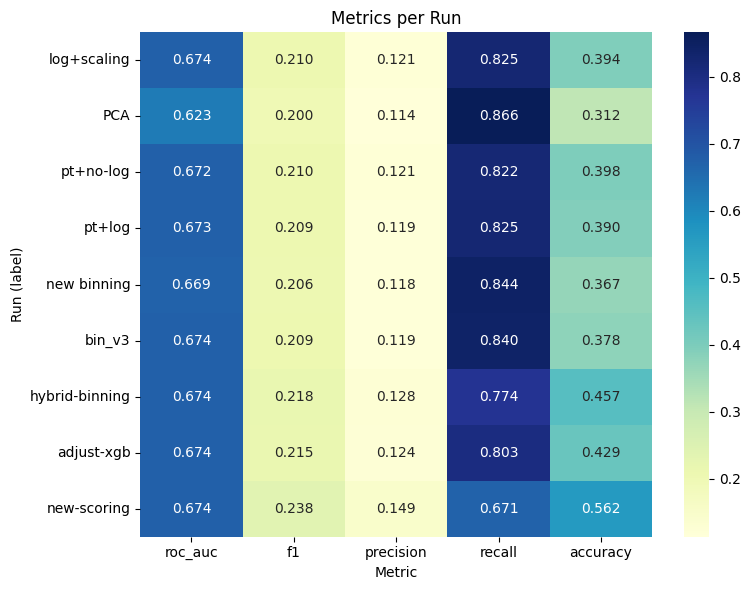

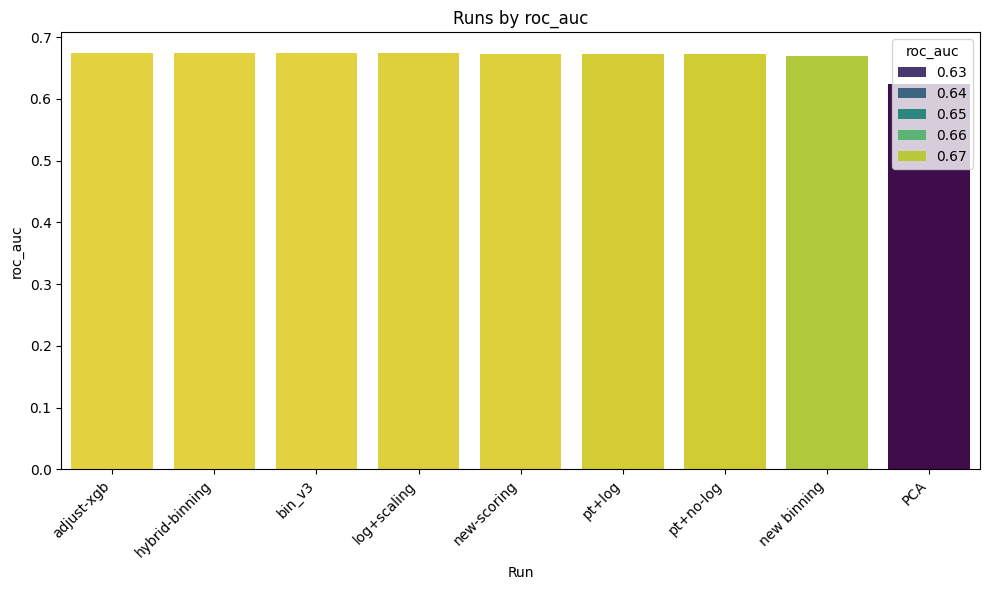

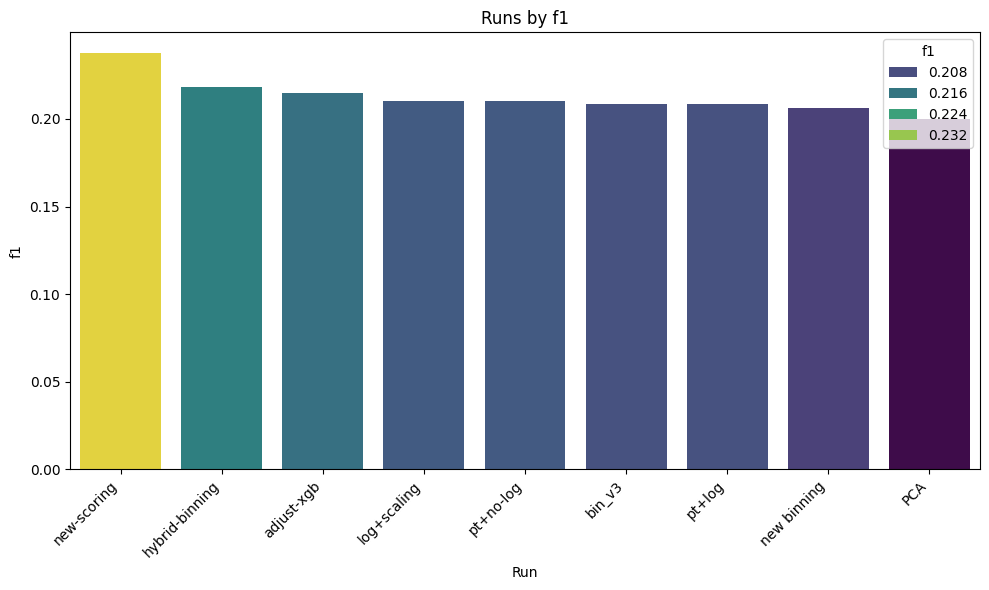

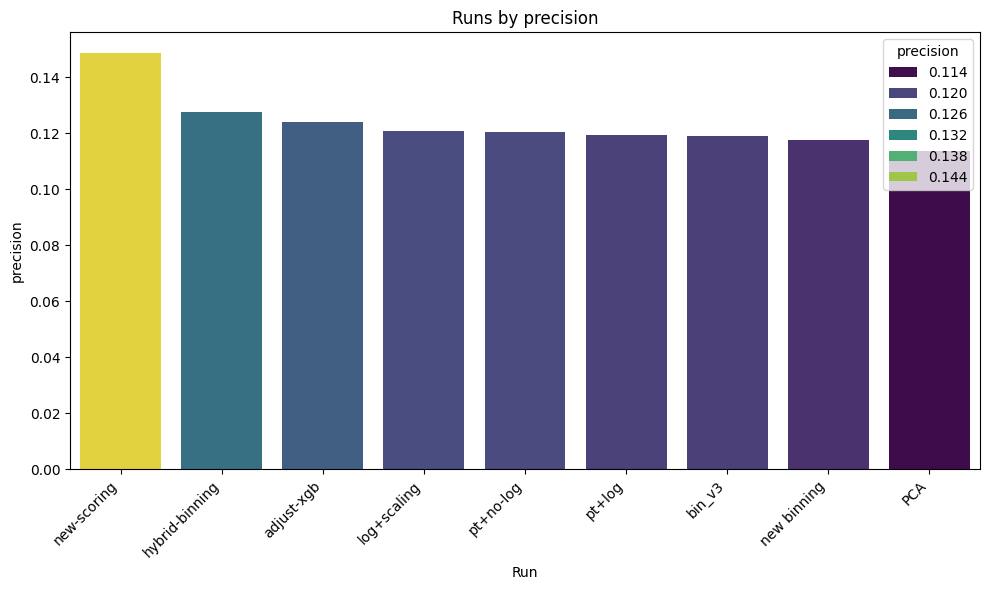

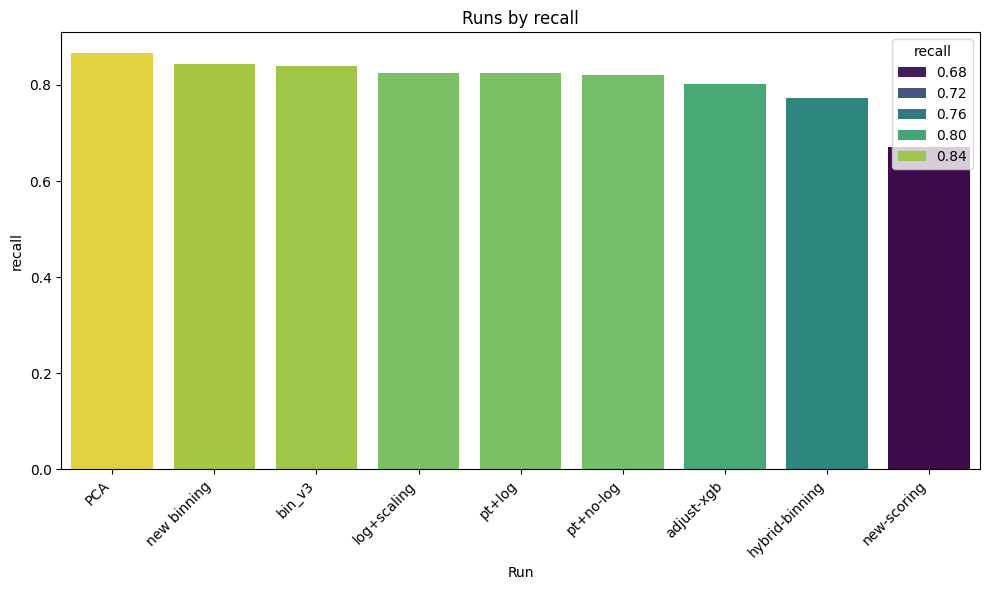

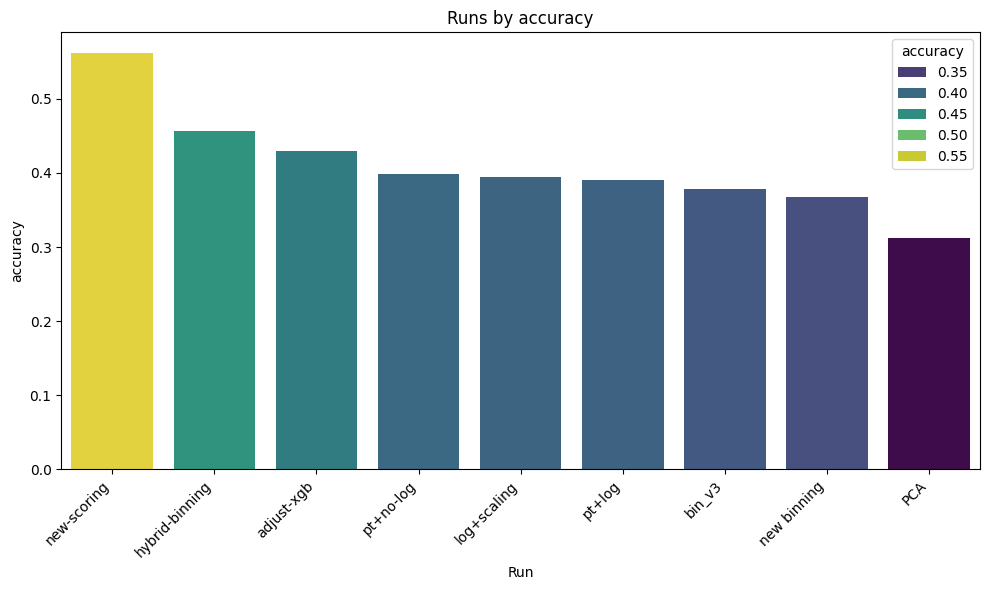

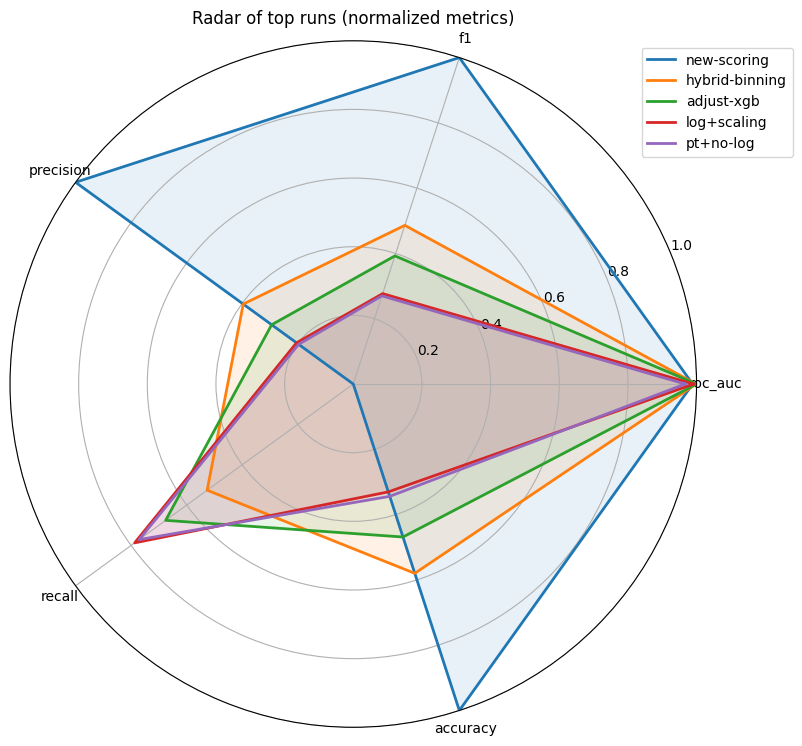

,run_id,label,roc_auc,f1,precision,recall,accuracy,rank_roc_auc,rank_f1,rank_precision,rank_recall,rank_accuracy,rank_sum,overall_score
0,10,new-scoring,0.673558,0.237569,0.148633,0.671373,0.561534,5.0,1.0,1.0,9.0,1.0,18.0,0.750000
1,8,hybrid-binning,0.674071,0.218267,0.127536,0.773892,0.456690,2.0,2.0,2.0,8.0,2.0,18.0,0.750000
2,9,adjust-xgb,0.674132,0.214753,0.123960,0.802997,0.428921,1.0,3.0,3.0,7.0,3.0,20.0,0.708333
3,1,log+scaling,0.673702,0.210414,0.120832,0.824718,0.394438,4.0,4.0,4.0,4.0,5.0,25.0,0.604167
4,3,pt+no-log,0.672461,0.210153,0.120568,0.821604,0.397838,7.0,5.0,5.0,6.0,4.0,32.0,0.458333
5,6,bin_v3,0.673936,0.208656,0.119211,0.840356,0.378241,3.0,6.0,7.0,3.0,7.0,33.0,0.437500
6,4,pt+log,0.672828,0.208591,0.119499,0.824500,0.390067,6.0,7.0,6.0,5.0,6.0,36.0,0.375000
7,5,new binning,0.669266,0.206300,0.117626,0.843831,0.367092,8.0,8.0,8.0,2.0,8.0,42.0,0.250000
8,2,PCA,0.623478,0.200012,0.113691,0.866203,0.311991,9.0,9.0,9.0,1.0,9.0,46.0,0.166667


In [4]:
from shared_util.metrics.compare import compare_runs

compare_runs(
    df=df_label,
    metric_cols=["roc_auc", "f1", "precision", "recall", "accuracy"],
    weights={"precision": 2.0, "accuracy": 1.0}  # new scoring prioritize precision for lowering cost 
)

### Comparing Models

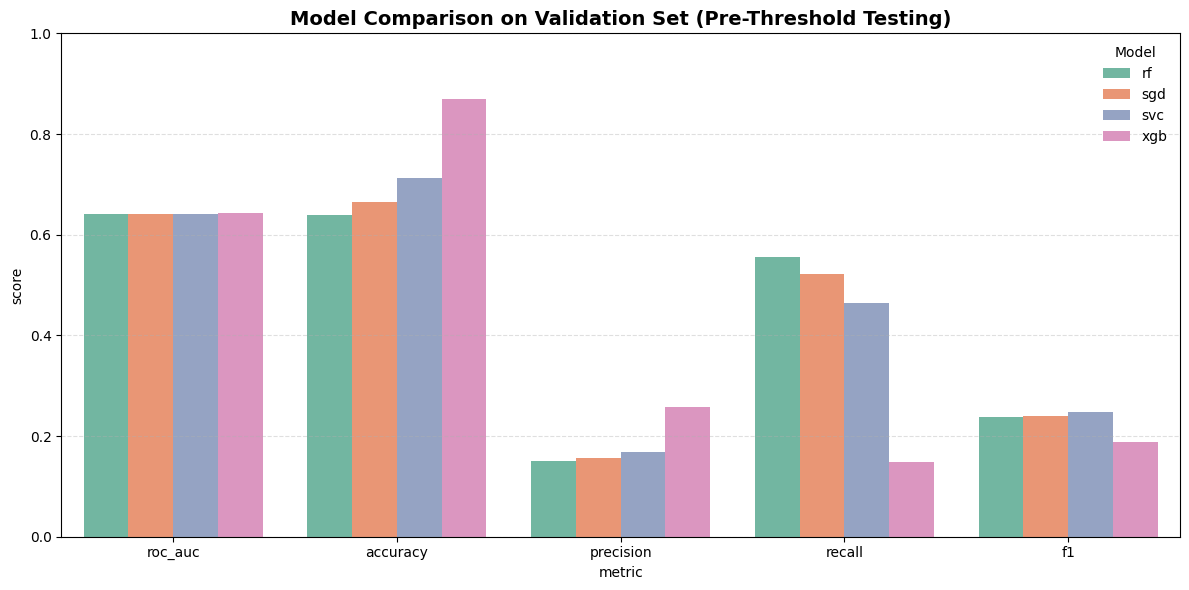

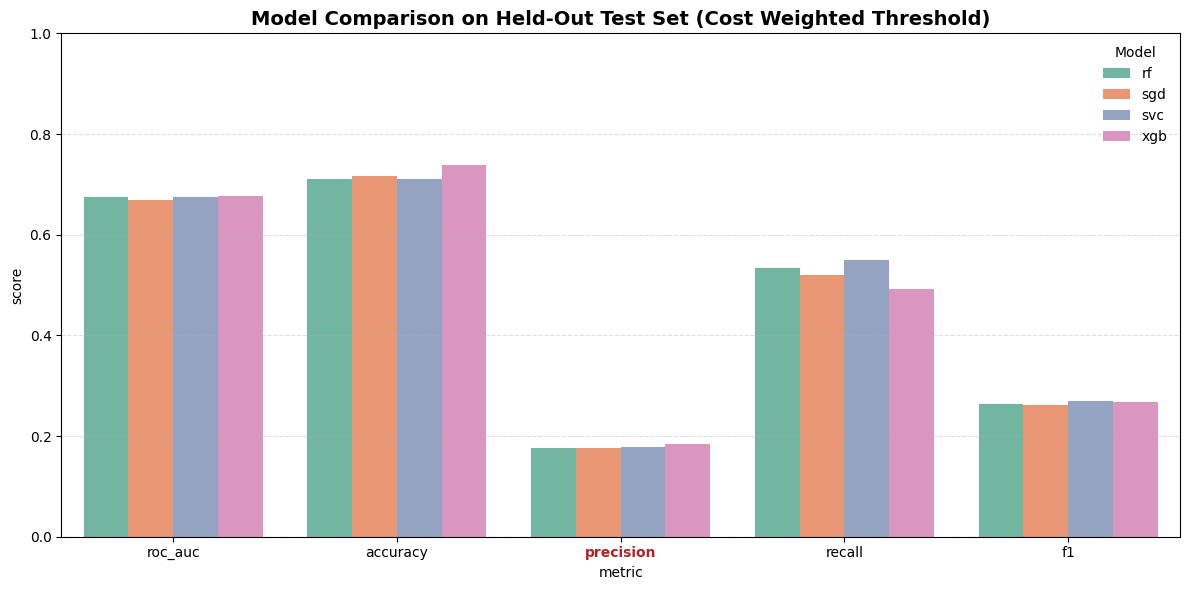

In [4]:
from shared_util.metrics.printing import summary_by_auc, summary_by_recall
from shared_util.metrics.plotting import plot_metrics

plot_metrics(most_recent_df, METRICS_DB_ID)

In [5]:
print('--most recent--')
summary_by_auc(most_recent_df, plot_id=METRICS_DB_ID)
summary_by_recall(most_recent_df)

# print('--no pca--')
# summary_by_auc(results_df, plot_id=1)
# summary_by_recall(results_df)



--most recent--
Models by ROC_AUC


,model,roc_auc
0,xgb,0.681
1,rf,0.676
2,svc,0.670
3,sgd,0.669


Models by Recall


,model,recall
7,sgd,0.891
4,svc,0.836
0,xgb,0.820
11,rf,0.814


### Hyperparameter Display

In [ ]:
from shared_util.fetch import fetch_params_by_id
import pandas as pd
import ast
import re

h_params_df = fetch_params_by_id(run_id=METRICS_DB_ID)

h_params_df.head(5)


_np_wrapper = re.compile(r"np\.(?:float|int)\d+\(([^)]+)\)")

def parse_hyperparams(text: str) -> pd.DataFrame:
    cleaned = _np_wrapper.sub(r"\1", text)
    params = ast.literal_eval(cleaned)

    def normalize(value):
        if isinstance(value, np.generic):
            return value.item()
        return value

    data = {k: normalize(v) for k, v in params.items()}
    return pd.DataFrame(data.items(), columns=["param", "value"])

for row in h_params_df.itertuples():
    print(f'Model: {row.model}')
    display(parse_hyperparams(row.hyperparam_text)) # type: ignore


Model: xgb


,param,value
0,model__colsample_bytree,5.325258e-01
1,model__gamma,4.744428e+00
2,model__learning_rate,2.900333e-01
3,model__max_depth,3.000000e+00
4,model__min_child_weight,9.000000e+00
5,model__n_estimators,7.640000e+02
6,model__reg_alpha,4.132918e-07
7,model__reg_lambda,5.285382e-02
8,model__scale_pos_weight,1.614304e+01
9,model__subsample,8.049983e-01


Model: svc


,param,value
0,model__C,4.418442
1,model__class_weight,balanced
2,model__gamma,0.001
3,model__kernel,rbf
4,model__shrinking,False


Model: sgd


,param,value
0,model__tol,0.001
1,model__shuffle,True
2,model__penalty,l2
3,model__max_iter,100
4,model__loss,hinge
5,model__learning_rate,adaptive
6,model__l1_ratio,0.5
7,model__eta0,0.0003
8,model__class_weight,None
9,model__average,True


# Random Forest

After reading (Liu, V. et al.) and (Mahmoud, M. et al.) I decided to begin expirementing with random forest models instead of logistic regression models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

### Define Pipeline

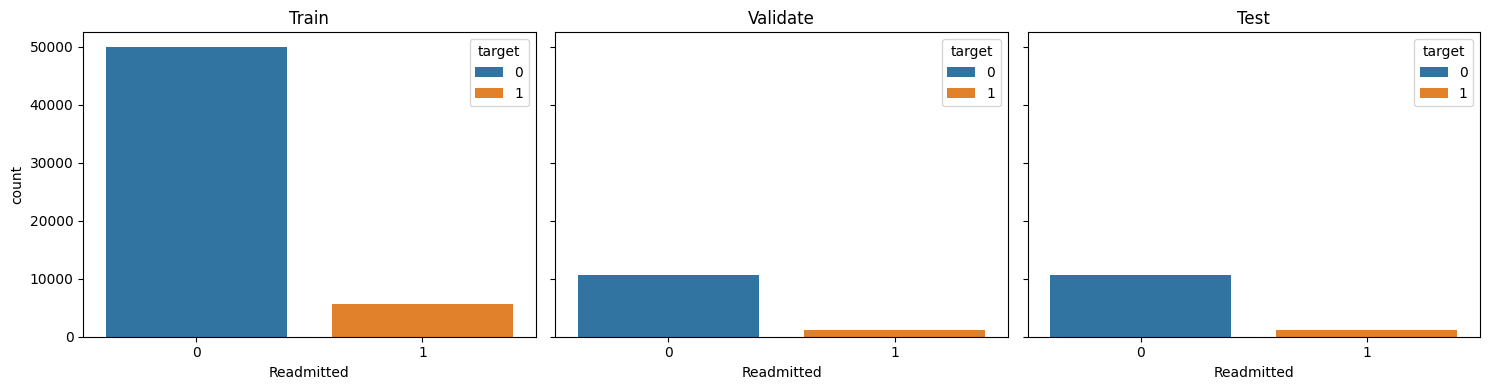

In [3]:

model = 'rf' # Random Forest


model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,        
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=True,                # show the target distribution between splits   
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model=model,
    scaler=None,
    group_by_col='patient_nbr',
    create_interactions=False, # no interaction terms for tree models
    one_hot_ordinal=False, # no one-hot encoding for tree models, use int based grouping
)

### Baseline

Get a baseline before looking at feature importance or hyperparameter tuning

We can use this baseline to check class imbalance approach methods, as well as to get a sense if this model can learn anything from the engineered features

In [4]:
model_pipe.run_baseline(
    run_smote=True,
    run_undersampler=True,
    show_duration_info=True,
)

--------SMOTE Baseline--------
roc_auc score per fold:  [0.59  0.599 0.594 0.602 0.586]
mean roc_auc score: , 0.594
connected to database
-----Undersample Baseline-----
roc_auc score per fold:  [0.641 0.634 0.623 0.652 0.627]
mean roc_auc score: , 0.635
Duration: 0 hrs, 0 mins, 20.2 secs


After several iterations of data cleaning tweaks, baseline SMOTE is performing significantly better with mean ROC of ~0.59

However the random under sampler still outperforms with a mean AUC_ROC of ~0.63

SMOTE performed worse than under sampling so we will stick with under sampling going forward

A mean ROC_AUC score of 0.630 implies that the model has learned something from the data so we will continue analysis.

### Feature Importance

- Tree impurity based importance is naturaly skewed to favor continuous features
- Permutation importance is model agnostic, is uneffected by the large class imbalance, and is not effected by the under sampling technique used

,feature,importance_mean,importance_std
4,number_inpatient,0.069337,0.007399
5,number_diagnoses,0.003936,0.001551
3,num_medications,0.002776,0.004569
1,num_lab_procedures,0.002603,0.000981
13,diag1_group_respiratory,0.002541,0.001461
0,time_in_hospital,0.002358,0.001697
35,specialty_cat_cardiology,0.002161,0.000345
59,v_emergency_group_several,0.001551,0.000569
49,admit_type_group_elective,0.001487,0.001395
56,v_emergency_group_few,0.001238,0.001340


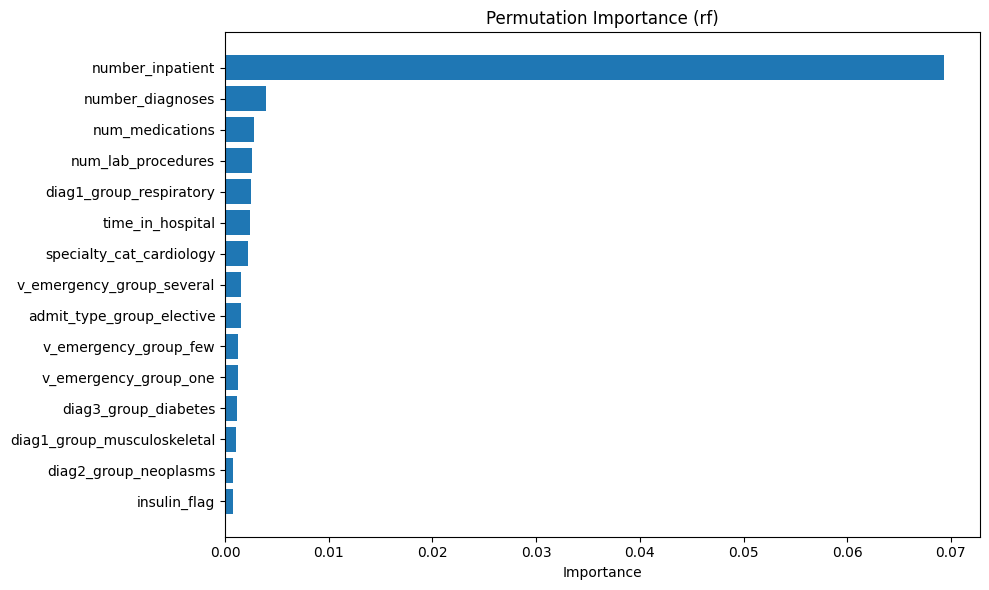

Duration: 0 hrs, 0 mins, 43.6 secs


In [5]:
model_pipe.permute_importance(
    print_num=15,
    plot=True,
    show_duration_info=True
)

In [6]:
param_grid = {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10, 15, 20],
        'model__min_samples_leaf': [1, 2, 4, 6, 10],
        'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
        'model__class_weight': [None, 'balanced'],
        'model__bootstrap': [True, False],
        'model__oob_score': [True, False]
    }

model_pipe.run_hyperparam_search(
    hyperparam_dist=param_grid,
    param_scoring='roc_auc',
    n_iter=30,
    n_jobs=-1,
    refit=True,
    show_duration_info=True
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6580816702000197
Best params: {'model__oob_score': True, 'model__n_estimators': 200, 'model__min_samples_split': 15, 'model__min_samples_leaf': 6, 'model__max_features': 'log2', 'model__max_depth': 10, 'model__class_weight': None, 'model__bootstrap': True}
logged hyperparameters
Duration: 0 hrs, 0 mins, 33.3 secs


### Validate

In [7]:
model_pipe.validate(
    show_duration_info=False,
    use_local_model=False
)

# model_pipe.validate(
#     show_duration_info=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

Held out validation metrics: rf
ROC_AUC:     0.6412181503164449
Accuracy:      0.6385410538700731
F1 score:      0.2378167641325536
Precision:     0.1512965050732807
Recall:        0.5554635761589404

Confusion matrix:

TN: 6927, FP: 3764, FN: 537, TP: 671

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.65      0.76     10691
           1       0.15      0.56      0.24      1208

    accuracy                           0.64     11899
   macro avg       0.54      0.60      0.50     11899
weighted avg       0.85      0.64      0.71     11899



### Test

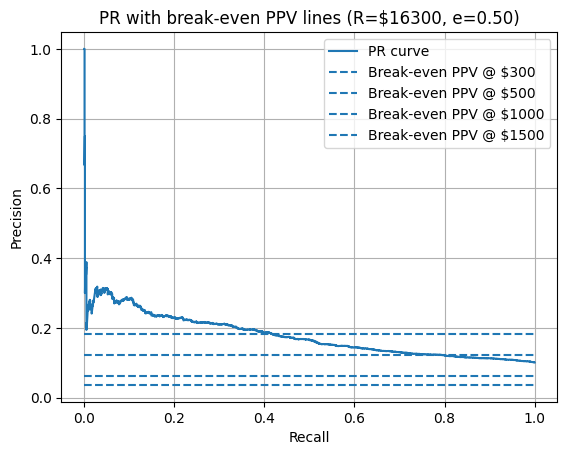

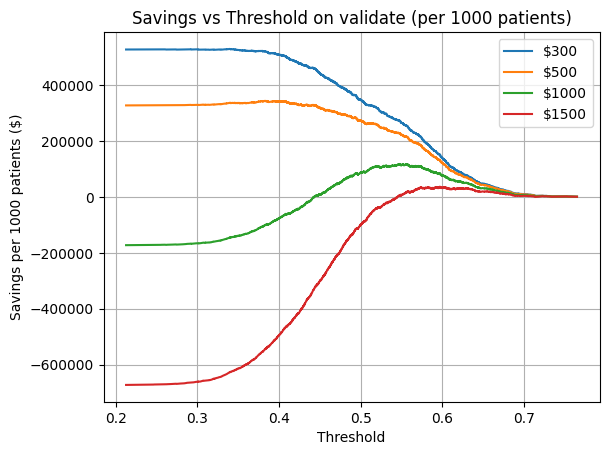

[COST] Chosen threshold: 0.5190 | PPV=0.168  Recall=0.498  FlagRate=0.302  Savings@avg=163.49 per patient
ROC_AUC:     0.6746510779483605
Accuracy:      0.7107863839851338
F1 score:      0.26397248495270853
Precision:     0.17537846329620108
Recall:        0.5334491746307559

Confusion matrix:

TN: 7801, FP: 2887, FN: 537, TP: 614

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.73      0.82     10688
           1       0.18      0.53      0.26      1151

    accuracy                           0.71     11839
   macro avg       0.56      0.63      0.54     11839
weighted avg       0.86      0.71      0.77     11839



In [8]:
model_pipe.test(
    use_f2_threshold=False,
    show_duration_info=False,
    show_plot=True,
    use_local_model=False,
    use_cost_threshold=True,
    R=16_300,
    e=0.50,
    c_m_list=[300, 500, 1000, 1500],
    prefer_c_m=None,
)
# model_pipe.test(
#     use_f2_threshold=True,
#     show_duration_info=True,
#     show_plot=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

# Stochastic Gradient Descent Classifier

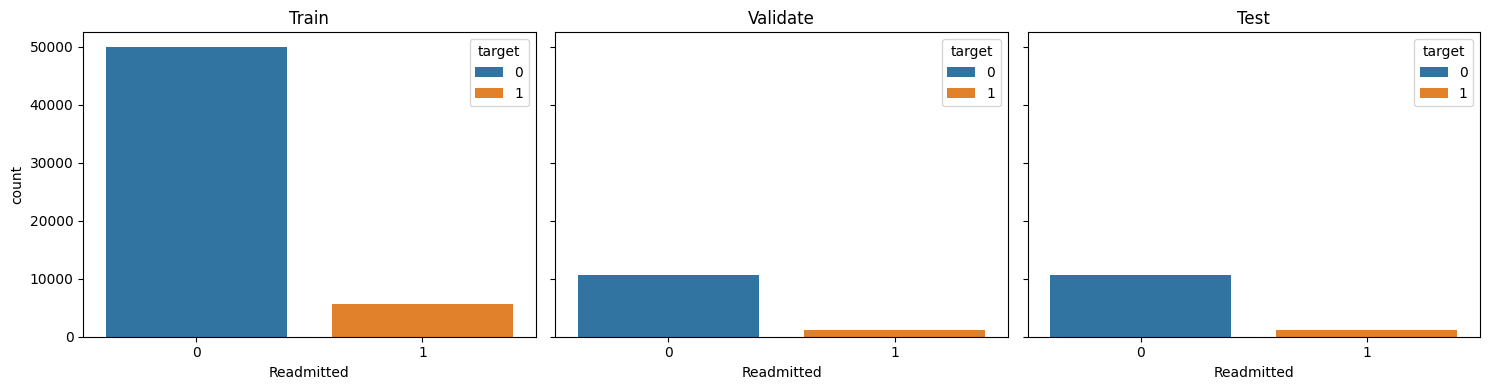

In [9]:
model = 'sgd' #SGDClassifier


sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model=model,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True,
    one_hot_ordinal=True
)



### Feature Importance

,feature,importance_mean,importance_std
4,number_inpatient,0.054963,0.006890
5,number_diagnoses,0.005669,0.003299
0,time_in_hospital,0.005173,0.004857
10,diag1_group_musculoskeletal,0.004845,0.001632
19,diag2_group_neoplasms,0.003122,0.001824
58,v_emergency_group_one,0.002674,0.001544
64,num_drugs,0.002634,0.000435
13,diag1_group_respiratory,0.002579,0.001355
56,v_emergency_group_few,0.002406,0.001642
3,num_medications,0.002375,0.002623


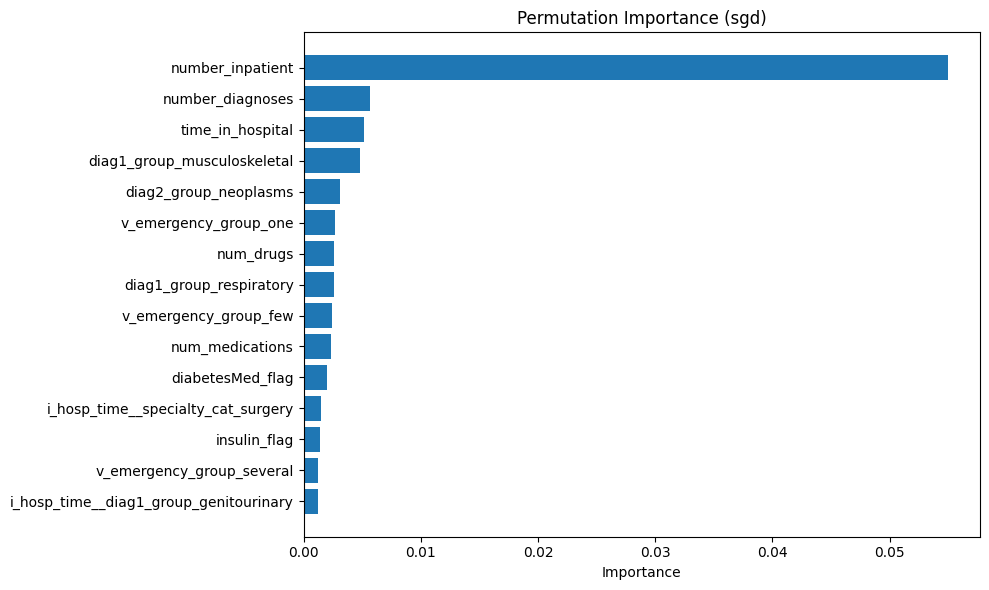

Duration: 0 hrs, 0 mins, 15.1 secs


In [10]:
if not PCA:
    sgd_pipe.permute_importance()

### Baseline

In [11]:
sgd_pipe.run_baseline() # all true

--------SMOTE Baseline--------
roc_auc score per fold:  [0.571 0.565 0.553 0.545 0.551]
mean roc_auc score: , 0.557
-----Undersample Baseline-----
roc_auc score per fold:  [0.596 0.597 0.617 0.603 0.619]
mean roc_auc score: , 0.606
Duration: 0 hrs, 0 mins, 12.3 secs


### Hyperparameter Search

In [12]:
sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6581712438338926
Best params: {'model__tol': 0.0001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 500, 'model__loss': 'modified_huber', 'model__learning_rate': 'invscaling', 'model__l1_ratio': 0.9, 'model__eta0': 0.003, 'model__class_weight': None, 'model__average': 10, 'model__alpha': 0.001}
logged hyperparameters
Duration: 0 hrs, 0 mins, 42.4 secs


### Validate

In [13]:
sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.6419034144582836
Accuracy:      0.6640053786032439
F1 score:      0.23992395437262357
Precision:     0.15572556762092793
Recall:        0.5223509933774835

Confusion matrix:

TN: 7270, FP: 3421, FN: 577, TP: 631

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.68      0.78     10691
           1       0.16      0.52      0.24      1208

    accuracy                           0.66     11899
   macro avg       0.54      0.60      0.51     11899
weighted avg       0.85      0.66      0.73     11899



### Test

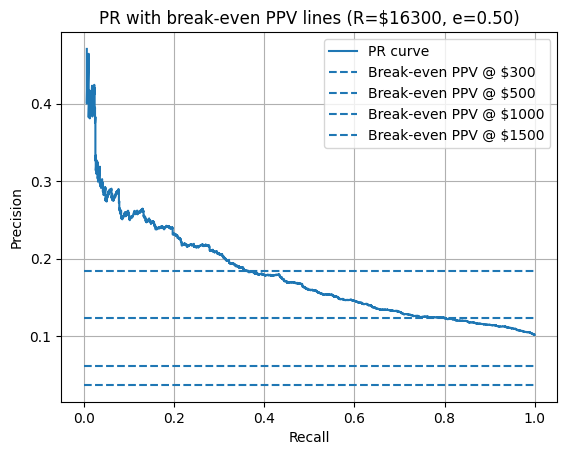

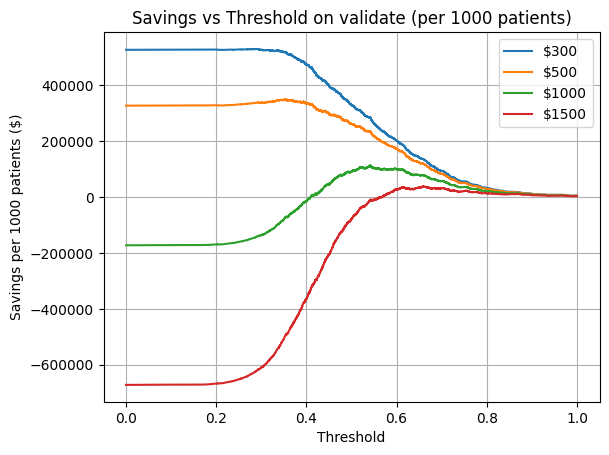

[COST] Chosen threshold: 0.5181 | PPV=0.167  Recall=0.484  FlagRate=0.294  Savings@avg=158.09 per patient
ROC_AUC:     0.6694076551501689
Accuracy:      0.7162767125601824
F1 score:      0.26256860592755216
Precision:     0.17567567567567569
Recall:        0.5195482189400521

Confusion matrix:

TN: 7882, FP: 2806, FN: 553, TP: 598

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.74      0.82     10688
           1       0.18      0.52      0.26      1151

    accuracy                           0.72     11839
   macro avg       0.56      0.63      0.54     11839
weighted avg       0.86      0.72      0.77     11839



In [14]:
sgd_pipe.test(
    use_f2_threshold=False,
    show_duration_info=False,
    show_plot=True,
    use_local_model=False,
    use_cost_threshold=True,
    R=16_300,
    e=0.50,
    c_m_list=[300, 500, 1000, 1500],
    prefer_c_m=None,
)

# Support Vector Classifier

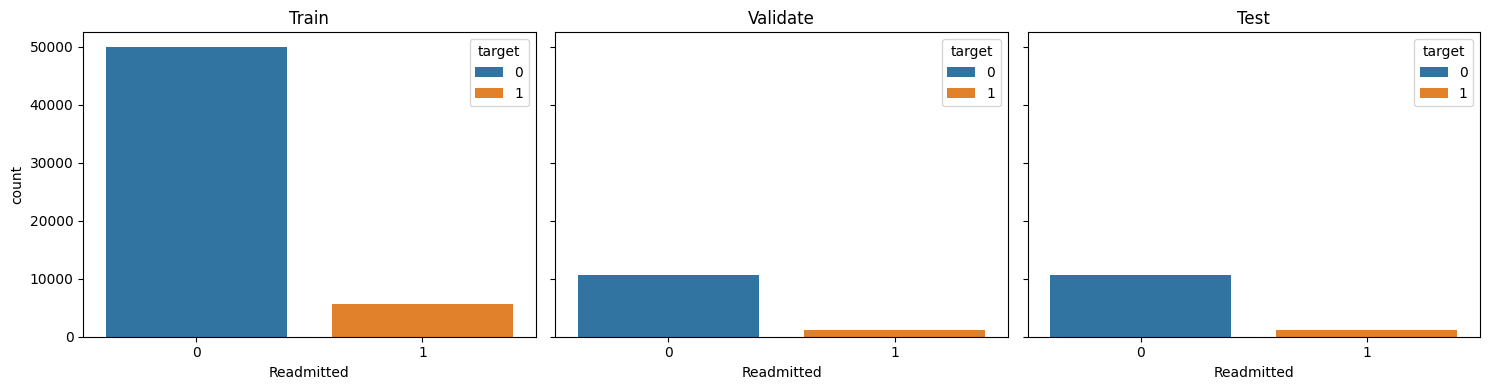

In [4]:

svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True,
    one_hot_ordinal=True
)

### Baseline

In [16]:
svc_pipe.run_baseline(run_smote=False) # smote did not complete after ~6 hours

-----Undersample Baseline-----
roc_auc score per fold:  [0.643 0.635 0.641 0.66  0.638]
mean roc_auc score: , 0.643
Duration: 0 hrs, 0 mins, 20.7 secs


### Feature Importance

In [17]:
# slow
# svc_pipe.permute_importance()

### Hyperparameter Search

In [18]:
from scipy.stats import loguniform
# slow

# limited param search due to computation time
svc_param_grid = {
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.0001, 0.001, 0.01, 0.1, 1],     
}

svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6581494263329176
Best params: {'model__C': np.float64(2.3973382079286494), 'model__gamma': 0.001}
logged hyperparameters
Duration: 0 hrs, 10 mins, 36.8 secs


### Validate

In [5]:

svc_pipe.validate(
    use_local_model=True,
    C=2.3973382079286494,
    gamma=.001
)

Held out validation metrics: svc
ROC_AUC:     0.6411854744443708
Accuracy:      0.7122447264476006
F1 score:      0.24714160070360597
Precision:     0.16826347305389222
Recall:        0.4652317880794702

Confusion matrix:

TN: 7913, FP: 2778, FN: 646, TP: 562

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.74      0.82     10691
           1       0.17      0.47      0.25      1208

    accuracy                           0.71     11899
   macro avg       0.55      0.60      0.53     11899
weighted avg       0.85      0.71      0.76     11899

connected to database


### Test

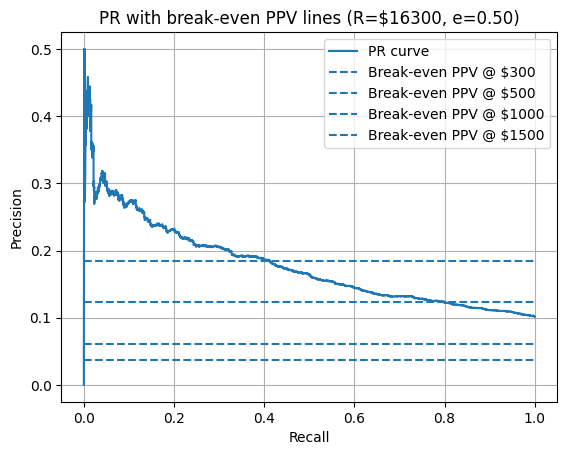

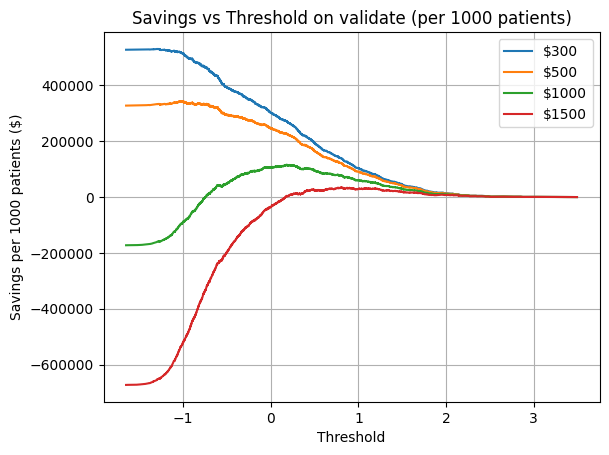

[COST] Chosen threshold: -0.0660 | PPV=0.166  Recall=0.498  FlagRate=0.305  Savings@avg=160.37 per patient
ROC_AUC:     0.6741491224761598
Accuracy:      0.7100261846439733
F1 score:      0.26941902532453715
Precision:     0.17841037204058624
Recall:        0.5499565595134666

Confusion matrix:

TN: 7773, FP: 2915, FN: 518, TP: 633

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.73      0.82     10688
           1       0.18      0.55      0.27      1151

    accuracy                           0.71     11839
   macro avg       0.56      0.64      0.54     11839
weighted avg       0.86      0.71      0.77     11839



In [6]:
svc_pipe.test(
    use_f2_threshold=False,
    show_duration_info=False,
    show_plot=True,
    use_cost_threshold=True,
    R=16_300,
    e=0.50,
    c_m_list=[300, 500, 1000, 1500],
    prefer_c_m=None,
    use_local_model=True,
    C=2.3973382079286494,
    gamma=.001
)

# XGBoost

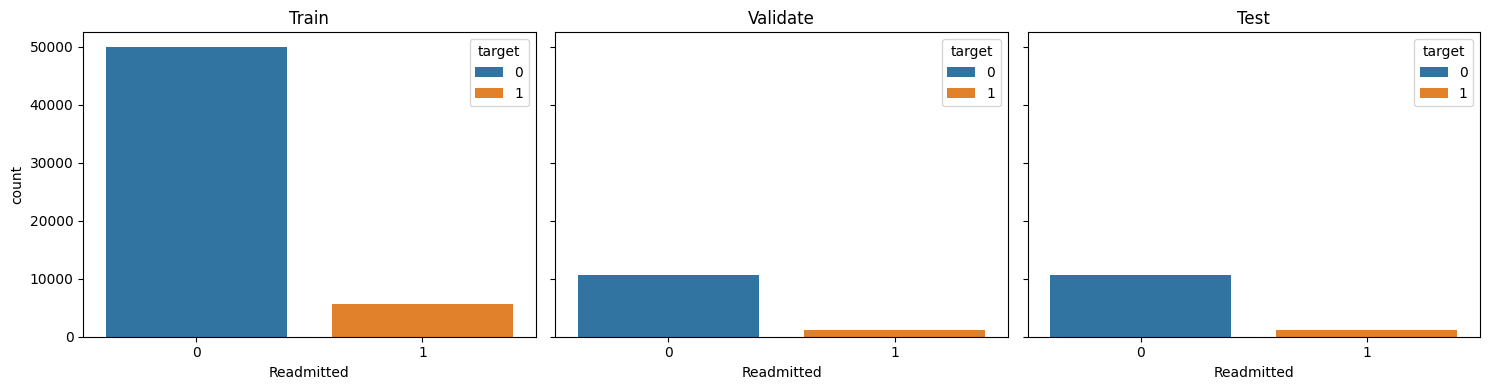

In [7]:
xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    create_interactions=False,
    log_transform_cols=np.array([]),
    use_pca=PCA,
    scaler=None,
    one_hot_ordinal=False,
    resample=False # handled by hyperparameters
)

In [22]:
xgb_pipe.run_baseline()

--------SMOTE Baseline--------
roc_auc score per fold:  [0.63  0.63  0.634 0.642 0.629]
mean roc_auc score: , 0.633
-----Undersample Baseline-----
roc_auc score per fold:  [0.63  0.63  0.634 0.642 0.629]
mean roc_auc score: , 0.633
Duration: 0 hrs, 0 mins, 11.7 secs


,feature,importance_mean,importance_std
4,number_inpatient,0.064762,0.006243
3,num_medications,0.011992,0.001958
1,num_lab_procedures,0.009138,0.000646
5,number_diagnoses,0.006719,0.002786
0,time_in_hospital,0.005004,0.001510
2,num_procedures,0.003560,0.002799
35,specialty_cat_cardiology,0.003401,0.001105
13,diag1_group_respiratory,0.003138,0.001289
42,age_group_30-60,0.002667,0.001125
64,num_drugs,0.002491,0.001898


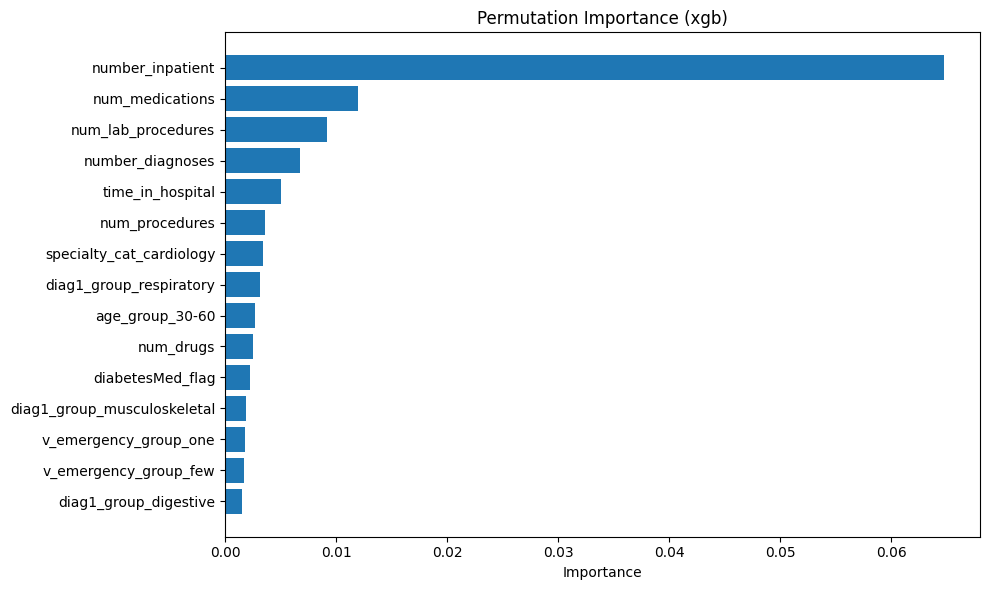

Duration: 0 hrs, 0 mins, 18.7 secs


In [23]:
if not PCA:
    xgb_pipe.permute_importance()

In [8]:
param_dist = {
    'model__max_depth': [3,4,5],
    'model__min_child_weight': [1,2,4],
    'model__subsample': [0.6,0.8,1.0],
    'model__colsample_bytree': [0.6,0.8,1.0],
    'model__gamma': [0,1,3],
    'model__learning_rate': [0.02, 0.05, 0.1],
    'model__scale_pos_weight': [1,2,4,6,8,10]
}

xgb_pipe.run_hyperparam_search(
    hyperparam_dist=param_dist
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6623979593997842
Best params: {'model__subsample': 0.6, 'model__scale_pos_weight': 4, 'model__min_child_weight': 2, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
logged hyperparameters
Duration: 0 hrs, 0 mins, 35.2 secs


In [9]:
xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.6437720174981617
Accuracy:      0.8701571560635347
F1 score:      0.1889763779527559
Precision:     0.2582496413199426
Recall:        0.1490066225165563

Confusion matrix:

TN: 10174, FP: 517, FN: 1028, TP: 180

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93     10691
           1       0.26      0.15      0.19      1208

    accuracy                           0.87     11899
   macro avg       0.58      0.55      0.56     11899
weighted avg       0.84      0.87      0.85     11899



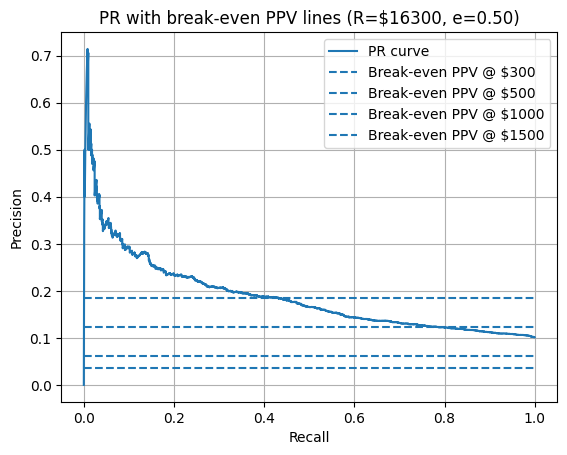

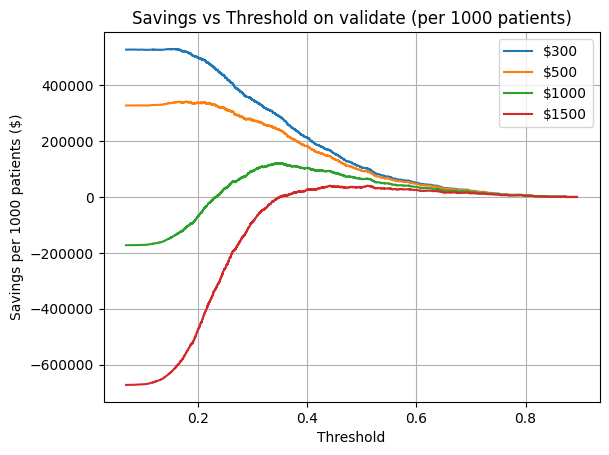

[COST] Chosen threshold: 0.3351 | PPV=0.177  Recall=0.471  FlagRate=0.271  Savings@avg=166.47 per patient
ROC_AUC:     0.6760256637030024
Accuracy:      0.7379846270799899
F1 score:      0.2673594709494568
Precision:     0.18358741485566007
Recall:        0.4917463075586447

Confusion matrix:

TN: 8171, FP: 2517, FN: 585, TP: 566

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.76      0.84     10688
           1       0.18      0.49      0.27      1151

    accuracy                           0.74     11839
   macro avg       0.56      0.63      0.55     11839
weighted avg       0.86      0.74      0.78     11839



In [10]:
xgb_pipe.test(
    use_f2_threshold=False,
    show_duration_info=False,
    show_plot=True,
    use_local_model=False,
    use_cost_threshold=True,
    R=16_300,
    e=0.50,
    c_m_list=[300, 500, 1000, 1500],
    prefer_c_m=None,
)

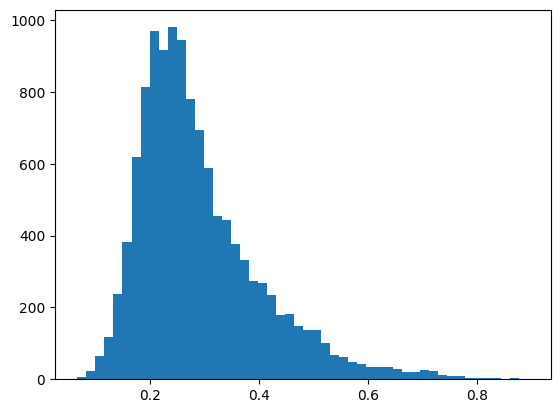

In [11]:
import matplotlib.pyplot as plt
from shared_util.dataio import load_csv



df = load_csv('cleaned')
from shared_util.split import group_split

X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)
plt.hist(xgb_pipe.randomized_search.best_estimator_.predict_proba(X_validate)[:,1], bins=50) #type: ignore
plt.show()
